# QLearning

## Description

`QLearning` is a **model-free, tabular RL algorithm** for discrete Markov Decision
Processes (MDPs). Unlike `ValueIteration` and `QValueIteration`, it does **not** build an
explicit transition model P(s′|s,a) or reward model R(s,a,s′). Instead, it updates the
state-action value function Q(s,a) **directly from single environment transitions** using
an off-policy TD(0) rule.

**Core Bellman update (applied after every environment step):**

$$Q[s,a] \leftarrow Q[s,a] + \alpha \cdot \left(r + \gamma \cdot \max_{a'} Q[s',a'] - Q[s,a]\right)$$

where α is the learning rate and the term in parentheses is the **TD error**.

Action selection is a **direct table lookup** — no model or recomputation required:

$$a^*(s) = \arg\max_{a} Q(s, a)$$

**Why model-free?**

- No need to store or invert an empirical P/R model — memory stays at O(|S||A|).
- Updates are **online**: every environment step immediately improves the Q-table.
- Off-policy: the behaviour policy (random exploration via `sample_env`) differs from
  the target policy (greedy argmax), making Q-learning theoretically sound even under
  exploration.
- Q-learning is the **direct precursor to DQN and quantum RL agents**: replace the
  Q-table with a neural network (or variational quantum circuit) and you get deep Q-learning.

**Inherits from:** nothing — `QLearning` is a standalone class. It does not inherit
`BaseIteration` because `BaseIteration` maintains large (n_s, n_a, n_s) model tensors
that Q-learning never uses.


## Constructor

```python
QLearning(
    env: gym.Env,
    gamma: float = 0.9,
    alpha: float = 0.2,
    num_test_episodes: int = 20,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = torch.float32,
)
```

| Parameter           | Type           | Default         | Description                                                            |
| ------------------- | -------------- | --------------- | ---------------------------------------------------------------------- |
| `env`               | `gym.Env`      | —               | Gymnasium / qrl-qai environment with **discrete** obs & action spaces. |
| `gamma`             | `float`        | `0.9`           | Discount factor in [0, 1). Higher → more far-sighted.                  |
| `alpha`             | `float`        | `0.2`           | Learning rate (step size) in (0, 1]. Controls how fast Q is updated.  |
| `num_test_episodes` | `int`          | `20`            | Informational; used by external training loops for evaluation.         |
| `device`            | `torch.device` | auto (CUDA/CPU) | Compute device for all tensors.                                        |
| `dtype`             | `torch.dtype`  | `float32`       | Floating-point precision for all tensors.                              |

The constructor calls `env.reset()` internally and initialises Q[s,a] = 0 for all (s,a).


## Implementation Details

### Environment interaction

| Method                        | Description                                                                              |
| ----------------------------- | ---------------------------------------------------------------------------------------- |
| `sample_env()`                | Take one **random** step in `self.env`. Returns `(state, action, reward, next_state)`.  |
| `play_episode(env)`           | Run one **greedy** episode on *env* (no updates). Returns total undiscounted reward.     |

### Learning

| Method                                          | Description                                                                 |
| ----------------------------------------------- | --------------------------------------------------------------------------- |
| `value_update(state, action, reward, next_state)` | Apply one TD(0) Q-learning update to Q[state, action].                    |

### Action selection & inspection

| Method / Property  | Description                                                                          |
| ------------------ | ------------------------------------------------------------------------------------ |
| `select_action(s)` | Greedy action: `argmax_a Q(s,a)`. O(|A|) direct table lookup. Returns `int`.        |
| `Q`                | Current Q-table tensor, shape `(n_states, n_actions)`.                               |
| `V`                | Derived state-value tensor `max_a Q(s,a)`, shape `(n_states,)`. Recomputed on access.|
| `get_policy()`     | Greedy policy tensor of shape `(n_states,)` — `argmax_a Q(s,a)` for every state.    |

### Internal state

| Attribute   | Shape                   | Description                                         |
| ----------- | ----------------------- | --------------------------------------------------- |
| `_Q`        | `(n_states, n_actions)` | Current Q-function tensor.                          |
| `_state`    | `int`                   | Current state of `self.env` (updated by `sample_env`). |


## QLearning vs. QValueIteration vs. ValueIteration

| Aspect                  | `ValueIteration`                    | `QValueIteration`                       | `QLearning`                                  |
| ----------------------- | ----------------------------------- | --------------------------------------- | -------------------------------------------- |
| Algorithm type          | Model-based planning                | Model-based planning                    | Model-free TD learning                       |
| Stored quantity         | V[s] — shape `(\|S\|,)`              | Q[s,a] — shape `(\|S\|, \|A\|)`         | Q[s,a] — shape `(\|S\|, \|A\|)`             |
| Memory                  | O(\|S\|) + O(\|S\|²\|A\|) model     | O(\|S\|\|A\|) + O(\|S\|²\|A\|) model   | O(\|S\|\|A\|) — **no model**                |
| Update trigger          | Full Bellman sweep over all (s,a)   | Full Bellman sweep over all (s,a)       | Single transition (s,a,r,s')                 |
| `select_action()` cost  | O(\|S\|\|A\|) — one-step lookahead  | O(\|A\|) — direct table lookup          | O(\|A\|) — direct table lookup               |
| Requires model          | Yes — P and R tensors               | Yes — P and R tensors                   | **No**                                       |
| Extension to deep RL    | Requires additional steps           | Closer — Q-table is explicit            | **Direct** — replace Q-table with neural net |
| Planning call           | `value_iteration()`                 | `qvalue_iteration()`                    | `value_update()` per step                    |

**Rule of thumb:** use `QLearning` when you want online, model-free learning, when memory
for the empirical model is a concern, or when you plan to extend to DQN or quantum RL agents.


---
## Example 1 — FrozenLake-v1 (stochastic environment)

`FrozenLake-v1` with `is_slippery=True` is a classic stochastic 4×4 grid benchmark.
The agent must navigate from the start cell to the goal without falling into holes;
each intended action succeeds with probability 1/3 (the rest is split between
two perpendicular directions).

Here `QLearning` learns **purely from experience** — no transition model is built.
At each outer iteration, one random transition is sampled from the environment and
the Q-table is updated with a single TD(0) step. The agent is then evaluated with
greedy rollouts. Note that Q-learning typically needs more iterations than model-based
methods to solve this environment, since each update uses only one transition rather
than a full Bellman sweep over all states.


In [4]:
import gymnasium as gym
from qrl.algorithms.classical import QLearning

env      = gym.make("FrozenLake-v1", is_slippery=True)
test_env = gym.make("FrozenLake-v1", is_slippery=True)

agent = QLearning(env=env, gamma=0.9, alpha=0.2)

print(f"State space  : {agent.n_states}   (one per grid cell)")
print(f"Action space : {agent.n_actions}   (left=0, down=1, right=2, up=3)")
print(f"Device       : {agent.device}")
print(f"Q shape      : {agent.Q.shape}")
print(f"V shape      : {agent.V.shape}   (derived from Q)")

State space  : 16   (one per grid cell)
Action space : 4   (left=0, down=1, right=2, up=3)
Device       : cpu
Q shape      : torch.Size([16, 4])
V shape      : torch.Size([16])   (derived from Q)


In [5]:
TEST_EPISODES = 20

iter_no     = 0
best_reward = 0.0

while True:
    iter_no += 1

    # Step 1 — interact: take one random step and apply a TD(0) Q-update
    state, action, reward, next_state = agent.sample_env()
    agent.value_update(state, action, reward, next_state)

    # Step 2 — evaluate: run TEST_EPISODES greedy episodes
    test_reward = sum(agent.play_episode(test_env) for _ in range(TEST_EPISODES))
    test_reward /= TEST_EPISODES

    if test_reward > best_reward:
        print(f"  ▶ Best reward updated {best_reward:.3f} → {test_reward:.3f}  "
              f"(iter {iter_no})")
        best_reward = test_reward

    if best_reward > 0.80:
        print(f"\nSolved in {iter_no} iterations!")
        break

  ▶ Best reward updated 0.000 → 0.050  (iter 998)
  ▶ Best reward updated 0.050 → 0.100  (iter 1003)
  ▶ Best reward updated 0.100 → 0.150  (iter 1036)
  ▶ Best reward updated 0.150 → 0.200  (iter 1037)
  ▶ Best reward updated 0.200 → 0.250  (iter 1105)
  ▶ Best reward updated 0.250 → 0.450  (iter 1132)
  ▶ Best reward updated 0.450 → 0.500  (iter 1701)
  ▶ Best reward updated 0.500 → 0.550  (iter 1720)
  ▶ Best reward updated 0.550 → 0.600  (iter 2562)
  ▶ Best reward updated 0.600 → 0.650  (iter 2601)
  ▶ Best reward updated 0.650 → 0.700  (iter 3624)
  ▶ Best reward updated 0.700 → 0.750  (iter 7202)
  ▶ Best reward updated 0.750 → 0.800  (iter 7204)
  ▶ Best reward updated 0.800 → 0.850  (iter 9233)

Solved in 9233 iterations!


In [6]:
policy = agent.get_policy()   # shape (16,)
action_symbols = {0: "←", 1: "↓", 2: "→", 3: "↑"}

print("Greedy policy (raw tensor):")
print(policy)

print("\nGreedy policy grid (4×4):")
grid = [[action_symbols[int(policy[r * 4 + c])] for c in range(4)] for r in range(4)]
for row in grid:
    print("  ", " ".join(row))

print("\nDerived V(s) = max_a Q(s,a) (reshaped to 4×4):")
print(agent.V.reshape(4, 4).round(decimals=3))

print("\nQ-table shape:", agent.Q.shape)
print("Q-table (states as rows, actions as columns):")
import torch
print(agent.Q.round(decimals=3))

Greedy policy (raw tensor):
tensor([0, 3, 0, 3, 0, 0, 0, 0, 3, 1, 0, 0, 0, 2, 2, 0])

Greedy policy grid (4×4):
   ← ↑ ← ↑
   ← ← ← ←
   ↑ ↓ ← ←
   ← → → ←

Derived V(s) = max_a Q(s,a) (reshaped to 4×4):
tensor([[0.0700, 0.0640, 0.0880, 0.0630],
        [0.0880, 0.0000, 0.1000, 0.0000],
        [0.1250, 0.2570, 0.2490, 0.0000],
        [0.0000, 0.2920, 0.7940, 0.0000]])

Q-table shape: torch.Size([16, 4])
Q-table (states as rows, actions as columns):
tensor([[0.0700, 0.0690, 0.0690, 0.0630],
        [0.0560, 0.0530, 0.0460, 0.0640],
        [0.0880, 0.0690, 0.0750, 0.0680],
        [0.0520, 0.0440, 0.0390, 0.0630],
        [0.0880, 0.0840, 0.0570, 0.0680],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.1000, 0.0520, 0.0720, 0.0230],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0460, 0.0590, 0.1060, 0.1250],
        [0.0880, 0.2570, 0.1470, 0.0730],
        [0.2490, 0.2490, 0.1380, 0.0670],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],

---
## Example 2 — BlochSphereV1 (quantum discrete MDP)

`BlochSphereV1` is a deterministic finite-graph MDP over the six canonical Bloch sphere states.
With only 6 states and 4 actions the Q-table is tiny (6 × 4 = 24 entries).

Because the environment is **deterministic**, a single visit to each (s,a) pair is enough
for the TD update to propagate accurate values — so `QLearning` converges quickly even
without an explicit model.

The `BlochSphereV1` renderer has **first-class support for Q-tables**: it detects `agent._Q`
and visualises:

- **Node colours** (right panel) — warm scale encoding `max_a Q(s,a)` per state.
- **Bold teal edges** — the greedy policy `argmax_a Q(s,a)` for each state.
- **Edge opacity** — proportional to empirical visit counts. Note: since `QLearning` does
  not maintain `_counts`, the renderer falls back to uniform opacity.
- **Colorbar** — min and max Q-value states are labelled.


In [1]:
from qrl.algorithms.classical import QLearning
from qrl.env import BlochSphereV1

# Target state index 4 → |+i⟩
# set ffmpeg=True if you have ffmpeg installed to save as mp4
env      = BlochSphereV1(target_state=4, max_steps=10, reward_tolerance=0.99, ffmpeg=False)
test_env = BlochSphereV1(target_state=4, max_steps=10, reward_tolerance=0.99, ffmpeg=False)

agent = QLearning(env=env, gamma=0.9, alpha=0.2)

print(f"State space  : {agent.n_states}  (|0⟩ |1⟩ |+⟩ |-⟩ |+i⟩ |-i⟩)")
print(f"Action space : {agent.n_actions}  (H=0, X=1, Z=2, S=3)")
print(f"Target state : {env.target_state_index}  → |+i⟩")
print(f"Q shape      : {agent.Q.shape}   (6 states × 4 actions)")
print()
print("Transition table T[s, a] = s':")
print(BlochSphereV1.transition_table())

State space  : 6  (|0⟩ |1⟩ |+⟩ |-⟩ |+i⟩ |-i⟩)
Action space : 4  (H=0, X=1, Z=2, S=3)
Target state : 4  → |+i⟩
Q shape      : torch.Size([6, 4])   (6 states × 4 actions)

Transition table T[s, a] = s':
[[2 1 0 0]
 [3 0 1 1]
 [0 2 3 4]
 [1 3 2 5]
 [5 5 5 3]
 [4 4 4 2]]


AttributeError: 'QLearning' object has no attribute '_counts'

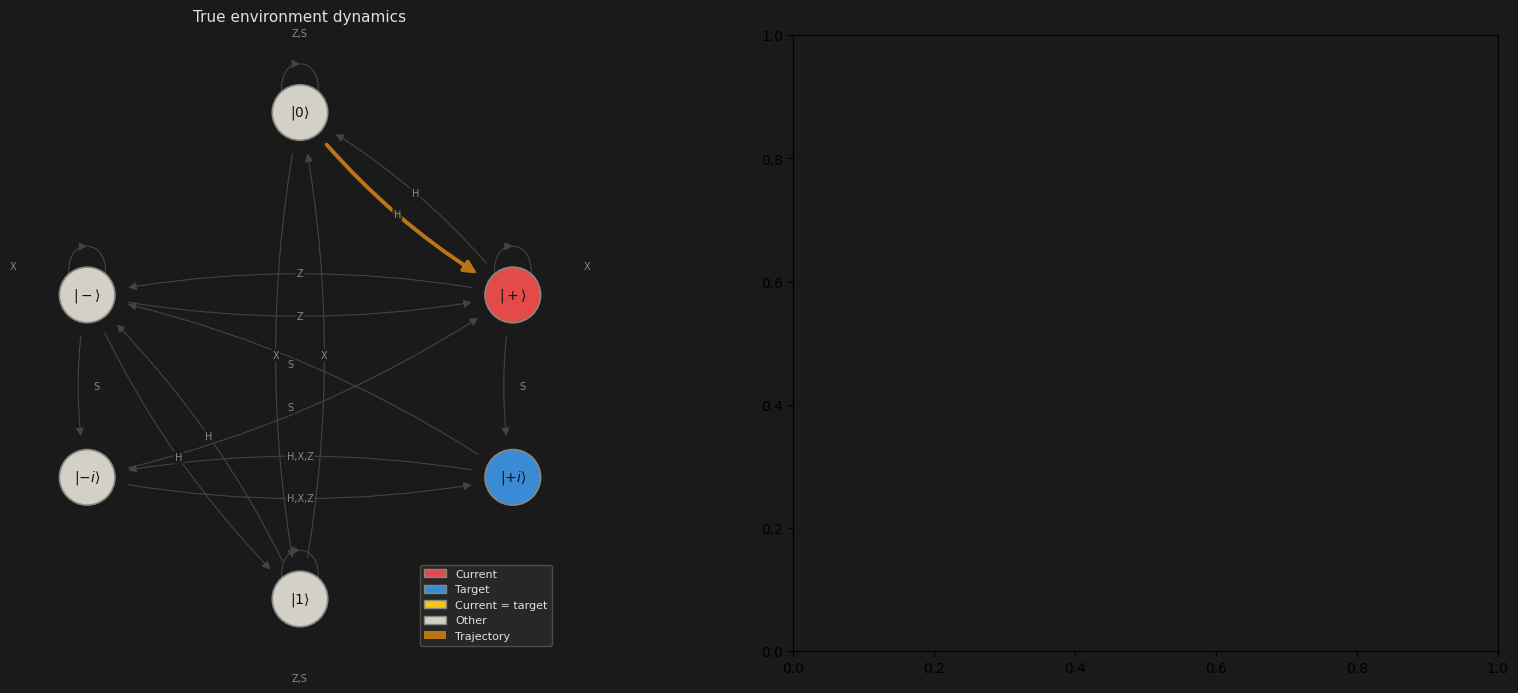

In [2]:
TEST_EPISODES = 20
iter_no, best_reward = 0, 0.0

while True:
    iter_no += 1

    # Interact: one random step → one TD(0) update
    state, action, reward, next_state = agent.sample_env()
    agent.value_update(state, action, reward, next_state)

    # Collect a graph snapshot for the animation
    env._render_graph(agent=agent)

    # Evaluate: measure success rate
    reward_eval = 0.0
    for _ in range(TEST_EPISODES):
        obs, _ = test_env.reset()
        while True:
            action_eval = agent.select_action(int(obs))
            obs, _, terminated, truncated, _ = test_env.step(action_eval)
            if terminated or truncated:
                reward_eval += float(terminated)   # 1.0 on success
                break
    reward_eval /= TEST_EPISODES

    if reward_eval > best_reward:
        print(f"  ▶ Best reward updated {best_reward:.3f} → {reward_eval:.3f}  (iter {iter_no})")
        best_reward = reward_eval
    if best_reward >= 1.0:
        print(f"\nSolved in {iter_no} iteration(s)!")
        break

In [ ]:
state_labels = ["|0⟩", "|1⟩", "|+⟩", "|-⟩", "|+i⟩", "|-i⟩"]
action_names  = ["H", "X", "Z", "S"]

policy = agent.get_policy()
print("Greedy policy (argmax_a Q(s,a)):")
for s, (label, a) in enumerate(zip(state_labels, policy)):
    marker = " ← target" if s == env.target_state_index else ""
    print(f"  s={s}  {label:<6}  →  {action_names[int(a)]}{marker}")

print("\nDerived V(s) = max_a Q(s,a):")
for s, (label, v) in enumerate(zip(state_labels, agent.V)):
    print(f"  s={s}  {label:<6}  V = {v:.4f}")

print("\nFull Q-table Q[s, a] (states as rows, actions as columns):")
header = "       " + "   ".join(f"{a:>5}" for a in action_names)
print(header)
for s, label in enumerate(state_labels):
    row = "   ".join(f"{agent.Q[s, a].item():>5.3f}" for a in range(agent.n_actions))
    print(f"  {label:<6} {row}")

# Save the learning animation
env.render(
    save_path_without_extension="bloch_sphere_qlearning",
    interval=600,
    ffmpeg=False,
)
print("\nAnimation saved → bloch_sphere_qlearning.gif")

## Implementation Notes & Extensions

* **Model-free vs. model-based**: `QLearning` never builds a P/R model. Each call to
  `value_update()` uses only the single observed transition (s,a,r,s'), making it strictly
  more sample-inefficient than `QValueIteration` on small MDPs — but far more scalable
  when the state space is large or the model is expensive to maintain.

* **Learning rate `alpha`**: Too large → noisy Q-values that oscillate; too small → slow
  convergence. `alpha=0.2` is a good default for FrozenLake. Decaying α over time (e.g.
  `α_t = 1/n(s,a)`) gives Watkins' convergence guarantee.

* **Discount factor `gamma`**: The Q-learning operator converges for any `γ ∈ [0, 1)`. Larger
  values make the agent more far-sighted but may slow convergence in sparse-reward settings.

* **Exploration policy**: `sample_env()` uses a uniformly random behaviour policy. For harder
  environments, replace it with ε-greedy: mix `agent.select_action(state)` with occasional
  random actions.

* **Off-policy property**: Q-learning is off-policy — the behaviour policy (random in
  `sample_env`) and the target policy (greedy argmax) can differ. This lets you reuse
  experience from any policy, which is the key ingredient in experience replay (DQN).

* **Extension to DQN**: Replace `_Q` (a PyTorch tensor) with a neural network
  `Q_θ(s, a)`. Gradient updates replace the TD scalar update. Add a replay buffer
  and a target network for stability — you get DQN.

* **Extension to quantum RL**: Replace `_Q` with a variational quantum circuit (VQC)
  whose output approximates Q(s,a). This is the bridge to quantum Q-learning agents
  available elsewhere in the `qrl` library.


## Version History

* **v0**: Initial implementation. Tabular model-free Q-learning over discrete MDPs.
  PyTorch tensor Q-table. Online TD(0) updates from single transitions.
  Compatible with any Gymnasium environment with `Discrete` observation and action spaces,
  including qrl-qai quantum environments such as `BlochSphereV1`.
  `BlochSphereV1` renderer detects `_Q` attribute for richer visualisation.


## References (Suggested Reading)

* Sutton, R. S., & Barto, A. G., *Reinforcement Learning: An Introduction* (2nd ed.),
  Chapter 6 (Temporal-Difference Learning) and Chapter 6.5 (Q-learning: Off-policy TD Control).
* Watkins, C. J. C. H. (1989). *Learning from Delayed Rewards.* PhD Thesis, Cambridge.
* Watkins, C. J. C. H., & Dayan, P. (1992). *Q-learning.* Machine Learning, 8(3-4), 279-292.
* Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning.* Nature.
  (DQN — the deep extension of Q-learning).
* Gymnasium documentation — `FrozenLake-v1` environment.
* Nielsen, M. A., & Chuang, I. L., *Quantum Computation and Quantum Information* —
  for the single-qubit gate definitions used in `BlochSphereV1`.
